# 00 · Python and NumPy for engineering calculations

**Goal:** the handful of Python ideas used in every later notebook - arrays, vectorisation,
functions, and plots - through one engineering problem.

**Problem.** Laminar flow in a pipe of radius $R$ has the parabolic velocity profile
$$u(r) = u_{\max}\left(1 - \frac{r^2}{R^2}\right).$$
What is the volumetric flow rate $Q = \int_0^R u(r)\,2\pi r\,dr$, and how does it compare with the
exact result $Q = \pi R^2 u_{\max}/2$?

**What you will learn**

- create NumPy arrays and compute with them without loops (vectorisation)
- write reusable functions with docstrings
- integrate sampled data with the trapezoidal rule and check the result against an exact value
- make a labelled plot

**Before you start:** basic Python syntax (variables, lists, `for` loops - e.g. the official Python tutorial); integrals  ·  **Time:** about 45 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

## Arrays instead of loops
A NumPy array holds many numbers; arithmetic applies element by element.

In [2]:
R, u_max = 0.01, 0.5            # m, m/s
r = np.linspace(0, R, 11)        # 11 radial positions
u = u_max * (1 - r**2 / R**2)    # the whole profile in one line - no loop
print(np.round(u, 4))

[0.5   0.495 0.48  0.455 0.42  0.375 0.32  0.255 0.18  0.095 0.   ]


## Vectorised code is also faster
The same calculation with a Python loop and with NumPy, on a million points:

In [3]:
import time
r_big = np.linspace(0, R, 1_000_000)

t0 = time.perf_counter()
u_loop = [u_max * (1 - ri**2 / R**2) for ri in r_big]
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
u_vec = u_max * (1 - r_big**2 / R**2)
t_vec = time.perf_counter() - t0
print(f"loop {t_loop*1e3:.1f} ms, vectorised {t_vec*1e3:.2f} ms  ->  {t_loop/t_vec:.0f}x faster")

loop 312.8 ms, vectorised 9.47 ms  ->  33x faster


## Functions make calculations reusable

In [4]:
def flow_rate(R, u_max, n=101):
    """Flow rate by the trapezoidal rule on n radial points."""
    r = np.linspace(0, R, n)
    integrand = u_max * (1 - r**2 / R**2) * 2 * np.pi * r
    return engmath.integrate.trapezoid(integrand, r)

exact = np.pi * R**2 * u_max / 2
for n in (5, 11, 101, 1001):
    Q = flow_rate(R, u_max, n)
    print(f"n = {n:>5}: Q = {Q*1e6:.6f} mL/s, relative error {abs(Q-exact)/exact:.1e}")

n =     5: Q = 73.631078 mL/s, relative error 6.2e-02
n =    11: Q = 77.754418 mL/s, relative error 1.0e-02
n =   101: Q = 78.531962 mL/s, relative error 1.0e-04
n =  1001: Q = 78.539738 mL/s, relative error 1.0e-06


## Inside the algorithm: the trapezoidal rule
The area under sampled data is approximated by trapezoids,
$\int f\,dx \approx \sum_i \tfrac12 (f_i + f_{i+1})(x_{i+1} - x_i)$. Here it is twice - as a loop (how
you would write it on paper) and vectorised (how NumPy wants it):

In [5]:
def trapezoid_loop(y, x):
    total = 0.0
    for i in range(len(x) - 1):
        total += 0.5 * (y[i] + y[i+1]) * (x[i+1] - x[i])
    return total

def trapezoid_vec(y, x):
    return np.sum(0.5 * (y[1:] + y[:-1]) * np.diff(x))

r = np.linspace(0, R, 101)
integrand = u_max * (1 - r**2 / R**2) * 2 * np.pi * r
print(trapezoid_loop(integrand, r), trapezoid_vec(integrand, r), engmath.integrate.trapezoid(integrand, r))

7.853196235811087e-05 7.853196235811086e-05 7.853196235811086e-05


All three agree. `y[1:]` and `y[:-1]` are the array shifted by one element - the standard NumPy
idiom for "next value" and "current value". The library function is the same idea:

In [6]:
show_source(engmath.integrate.trapezoid)

def trapezoid(y, x=None, dx: float = 1.0) -> float:
    """Trapezoidal rule for (possibly unevenly spaced) data. Error O(h^2)."""
    y = np.asarray(y, float)
    if x is None:
        return float(dx * (y.sum() - 0.5 * (y[0] + y[-1])))
    x = np.asarray(x, float)
    return float(np.sum(np.diff(x) * (y[1:] + y[:-1]) / 2))

The error falls by about 100x for every 10x more points - the signature of a **second-order**
method (error $\propto h^2$). Notebook 05 explains why.

## Plotting

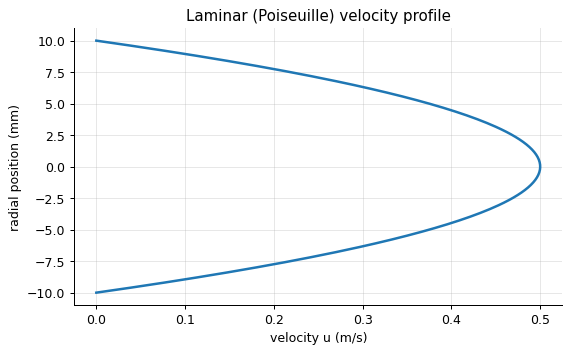

In [7]:
r = np.linspace(-R, R, 200)
fig, ax = plt.subplots()
ax.plot(u_max * (1 - r**2 / R**2), r * 1000, lw=2)
ax.set(xlabel="velocity u (m/s)", ylabel="radial position (mm)", title="Laminar (Poiseuille) velocity profile")
plt.show()

## Exercises
1. Turbulent profiles are flatter: $u = u_{\max}(1 - r/R)^{1/7}$. Compute $Q$ numerically and compare
   with the exact value $Q = \tfrac{49}{60}\pi R^2 u_{\max}$. Why does the trapezoidal rule converge
   more slowly here? (Hint: look at the derivative at $r = R$.)
2. Write a function `reynolds(rho, u, D, mu)` that works for scalars *and* arrays, and use it to plot
   Re against velocity for water in a 25 mm pipe.
3. **Implement it yourself:** write `midpoint(f, a, b, n)` for the midpoint rule, first with a loop and then vectorised. Time both for n = 10⁶ and compare their accuracy with the trapezoidal rule on the laminar profile.